In [1]:
import os
import torch
# Set GPU device
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# os.environ['http_proxy']  = 'http://192.41.170.23:3128'
# os.environ['https_proxy'] = 'http://192.41.170.23:3128'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
import datasets
import transformers
import torch
datasets.__version__, transformers.__version__, torch.__version__

c:\Users\Ishika\anaconda3\envs\nlpassignmnet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


('3.3.2', '4.49.0', '2.2.0')

In [3]:
import torch.nn as nn
import torch
from tqdm.auto import tqdm
import random, math, time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

#make our work comparable if restarted the kernel
SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

cuda


## 1. Loading our dataset

In [4]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("OxAISH-AL-LLM/wiki_toxic", split='train')
dataset



Dataset({
    features: ['id', 'comment_text', 'label'],
    num_rows: 127656
})

In [5]:
# Preprocess to match desired structure
dataset = dataset.rename_column("comment_text", "text")
dataset = dataset.remove_columns("id")


In [6]:

# Split into train, validation, and test
train_test_split = dataset.train_test_split(test_size=0.2, seed=42)
train = train_test_split["train"]
temp = train_test_split["test"]
valid_test_split = temp.train_test_split(test_size=0.5, seed=42)
valid = valid_test_split["train"]
test = valid_test_split["test"]

In [7]:
print(f"Train size: {len(train)}")
print(f"Validation size: {len(valid)}")
print(f"Test size: {len(test)}")



Train size: 102124
Validation size: 12766
Test size: 12766


In [8]:
from datasets import  DatasetDict
# Create DatasetDict
data_dict = DatasetDict({
    "train": train,
    "validation": valid,
    "test": test
})

data_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 102124
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12766
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12766
    })
})

In [9]:
print("Train sample:", train[0])

Train sample: {'text': 'hello mi name is liam bryant', 'label': 0}


In [10]:
# Label mappings
label_list = ['non-toxic', 'toxic']
label2id = {'non-toxic': 0, 'toxic': 1}
id2label = {0: 'non-toxic', 1: 'toxic'}


TRAIN Split (Total: 102124):
  non-toxic (0): 91778 samples (89.87%)
  toxic (1): 10346 samples (10.13%)

VALIDATION Split (Total: 12766):
  non-toxic (0): 11447 samples (89.67%)
  toxic (1): 1319 samples (10.33%)

TEST Split (Total: 12766):
  non-toxic (0): 11497 samples (90.06%)
  toxic (1): 1269 samples (9.94%)


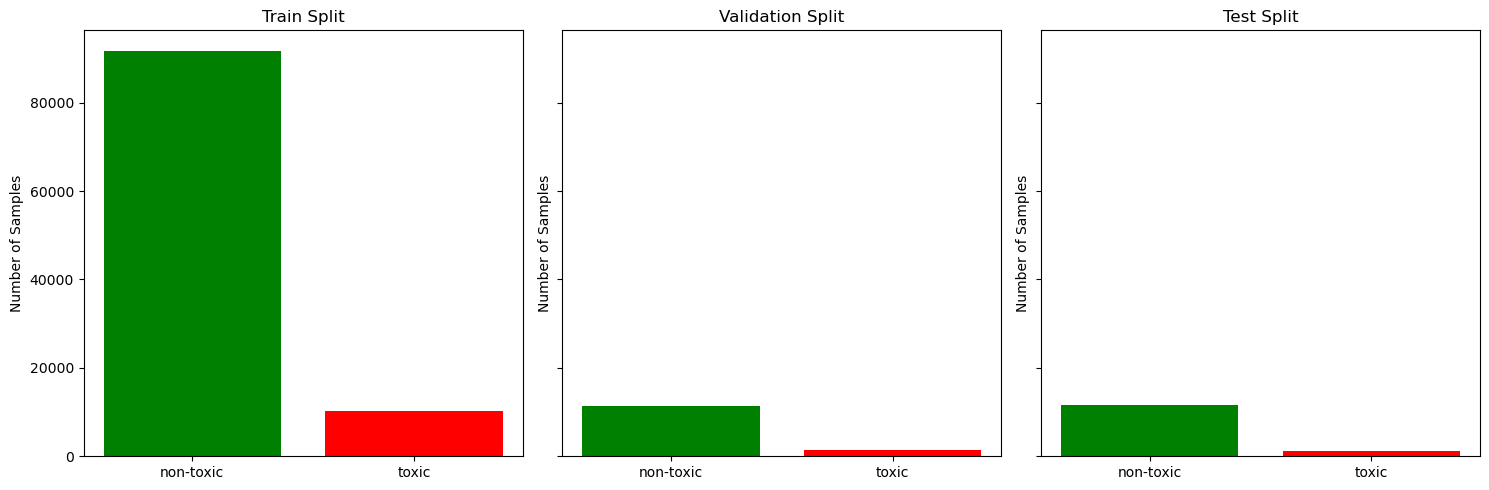

In [11]:
# Cell [65] - Check class imbalance
import numpy as np
from collections import Counter

# Function to compute class distribution
def check_class_distribution(dataset_dict):
    for split_name in ["train", "validation", "test"]:
        labels = dataset_dict[split_name]["label"]  # Extract labels
        label_counts = Counter(labels)  # Count occurrences of 0 and 1
        total = len(labels)
        
        # Print counts and percentages
        print(f"\n{split_name.upper()} Split (Total: {total}):")
        for label_id, count in label_counts.items():
            label_name = id2label[label_id]
            percentage = (count / total) * 100
            print(f"  {label_name} ({label_id}): {count} samples ({percentage:.2f}%)")

# Check distribution
check_class_distribution(data_dict)

# Optional: Visualize with matplotlib
import matplotlib.pyplot as plt

def plot_class_distribution(dataset_dict):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for ax, split_name in zip(axes, ["train", "validation", "test"]):
        labels = dataset_dict[split_name]["label"]
        label_counts = Counter(labels)
        counts = [label_counts.get(0, 0), label_counts.get(1, 0)]
        ax.bar(label_list, counts, color=['green', 'red'])
        ax.set_title(f"{split_name.capitalize()} Split")
        ax.set_ylabel("Number of Samples")
    plt.tight_layout()
    plt.show()

plot_class_distribution(data_dict)

In [12]:
# Cell [55] - Create DatasetDict
from datasets import DatasetDict


data_dict = DatasetDict({
    "train": train,
    "validation": valid,
    "test": test
})
data_dict

# Cell [56] - Downsample the train split
from datasets import concatenate_datasets
import numpy as np
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)

# Function to downsample majority class
def downsample_split(split_dataset, label_col="label", minority_label=1):
    # Separate minority and majority classes
    minority_data = split_dataset.filter(lambda x: x[label_col] == minority_label)
    majority_data = split_dataset.filter(lambda x: x[label_col] != minority_label)
    
    # Count minority samples
    minority_count = len(minority_data)
    print(f"Minority class (toxic) count in train: {minority_count}")
    
    # Randomly sample majority class to match minority count
    majority_indices = np.random.choice(len(majority_data), size=minority_count, replace=False)
    downsampled_majority = majority_data.select(majority_indices)
    
    # Combine and shuffle
    balanced_data = concatenate_datasets([minority_data, downsampled_majority])
    balanced_data = balanced_data.shuffle(seed=42)
    
    return balanced_data

# Downsample the train split
balanced_train = downsample_split(data_dict["train"])
data_dict["train"] = balanced_train

# Verify new distribution
print("\nUpdated data_dict after downsampling:")
print(data_dict)
for split_name in ["train", "validation", "test"]:
    labels = data_dict[split_name]["label"]
    label_counts = Counter(labels)
    total = len(labels)
    print(f"\n{split_name.upper()} Split (Total: {total}):")
    for label_id, count in label_counts.items():
        percentage = (count / total) * 100
        print(f"  {id2label[label_id]} ({label_id}): {count} samples ({percentage:.2f}%)")



Minority class (toxic) count in train: 10346

Updated data_dict after downsampling:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 20692
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12766
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12766
    })
})

TRAIN Split (Total: 20692):
  non-toxic (0): 10346 samples (50.00%)
  toxic (1): 10346 samples (50.00%)

VALIDATION Split (Total: 12766):
  non-toxic (0): 11447 samples (89.67%)
  toxic (1): 1319 samples (10.33%)

TEST Split (Total: 12766):
  non-toxic (0): 11497 samples (90.06%)
  toxic (1): 1269 samples (9.94%)


In [13]:
data_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 20692
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12766
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12766
    })
})

## 2. Model & Tokenization

In [14]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer

NUM_LABELS = len(label2id)

teacher_id = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(teacher_id)

teacher_model = AutoModelForSequenceClassification.from_pretrained(
    teacher_id, 
    num_labels = NUM_LABELS,
    id2label = id2label,
    label2id = label2id,
)

teacher_model

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

## 3. Preprocessing 

In [15]:
# Define tokenization function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Tokenize the combined dataset
tokenized_dataset = data_dict.map(tokenize_function, batched=True,remove_columns=["text"])



Map: 100%|██████████| 12766/12766 [00:01<00:00, 11398.48 examples/s]


In [16]:
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20692
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12766
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12766
    })
})

In [17]:
tokenized_dataset['train'][0]['input_ids'].shape

torch.Size([128])

In [18]:
tokenizer.decode(tokenized_dataset['train'][0]['input_ids'])

'[CLS] are both toponyms of greek origin, but the greek version of the name has not been included in neither of the relative articles. if you want to explain the ethymology of the toponym, you can do it below, but i would recommend you not to use the cyrillic alphabet since it is unreadable for the common english speaker. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

## 4. Preparing the dataloader

In [19]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [20]:
small_train_dataset = tokenized_dataset["train"].shuffle(seed=SEED).select(range(10000))
small_eval_dataset = tokenized_dataset["validation"].shuffle(seed=SEED).select(range(1000))
small_test_dataset = tokenized_dataset["test"].shuffle(seed=SEED).select(range(1000))

In [21]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(
    small_train_dataset, shuffle=True, batch_size=32, collate_fn=data_collator)
test_dataloader = DataLoader(
    small_test_dataset, batch_size=32, collate_fn=data_collator)
eval_dataloader = DataLoader(
    small_eval_dataset, batch_size=32, collate_fn=data_collator)

In [22]:
for batch in train_dataloader:
    break
    
batch['labels'].shape, batch['input_ids'].shape, batch['attention_mask'].shape

(torch.Size([32]), torch.Size([32, 128]), torch.Size([32, 128]))

## 5. Design the model and losses

### 5.1 Teacher Model & Student Model

####  Architecture 
In the present work, the student - DistilBERT - has the same general architecture as BERT. 
- The `token-type embeddings` and the `pooler` are removed while `the number of layers` is reduced by a factor of 2. 
- Most of the operations used in the Transformer architecture `linear layer` and `layer normalisation` are highly optimized in modern linear algebra frameworks.
- our investigations showed that variations on the last dimension of the tensor (hidden size dimension) have a smaller impact on computation efficiency (for a fixed parameters budget) than variations on other factors like the number of layers. 
- Thus we focus on reducing the number of layers.

#### Initialize Student Model
- To initialize a new model from an existing one, we need to access the weights of the old model (the teacher). 
- In order to get the weights, we first have to know how to access them. We’ll use BERT as our teacher model.

In [23]:
teacher_model.config

BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "non-toxic",
    "1": "toxic"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "non-toxic": 0,
    "toxic": 1
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.49.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

#### 
- The student model has the same configuration, except the number of layers is reduced by a factor of 2
- The student layers are initilized by copying one out of two layers of the teacher, starting with layer 0.
- The head of the teacher is also copied.

In [24]:
from transformers.models.bert.modeling_bert import BertPreTrainedModel, BertConfig
# Get teacher configuration as a dictionnary
configuration = teacher_model.config.to_dict()

In [25]:
configuration_even = configuration.copy()
configuration_even['num_hidden_layers'] //= 2

In [26]:
configuration_odd = configuration.copy()
configuration_odd['num_hidden_layers'] //= 2

In [27]:
# Convert to BertConfig
configuration_even = BertConfig.from_dict(configuration_even)
configuration_odd = BertConfig.from_dict(configuration_odd)

In [28]:
model_even = type(teacher_model)(configuration_even)
model_even

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [29]:
model_odd = type(teacher_model)(configuration_odd)
model_odd

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

- Recursively copies the weights of the (teacher) to the (student).
- This function is meant to be first called on a BertFor... model, but is then called on every children of that model recursively.
- The only part that's not fully copied is the encoder, of which only half is copied.

In [30]:
from transformers.models.bert.modeling_bert import BertEncoder, BertModel
from torch.nn import Module

def distill_bert_weights_odd_layers(
    teacher : Module,
    student : Module,
) -> None:
    """
    Recursively copies the odd weights of the (teacher) to the (student).
    This function is meant to be first called on a BertFor... model, but is then called on every children of that model recursively.
    The only part that's not fully copied is the encoder, of which only half is copied.
    """
    # If the part is an entire BERT model or a BERTFor..., unpack and iterate
    if isinstance(teacher, BertModel) or type(teacher).__name__.startswith('BertFor'):
        for teacher_part, student_part in zip(teacher.children(), student.children()):
            distill_bert_weights_odd_layers(teacher_part, student_part)
    # Else if the part is an encoder, copy one out of every layer
    elif isinstance(teacher, BertEncoder):
        teacher_encoding_layers = [layer for layer in next(teacher.children())] #12 layers
        student_encoding_layers = [layer for layer in next(student.children())] #6 layers
        for i in range(len(student_encoding_layers)):
            # getting even-indexed layers but the position is odd
            student_encoding_layers[i].load_state_dict(teacher_encoding_layers[2*i].state_dict())
    # Else the part is a head or something else, copy the state_dict
    else:
        student.load_state_dict(teacher.state_dict())

    return student

In [31]:
def distill_bert_weights_even_layers(
    teacher : Module,
    student : Module,
) -> None:
    """
    Recursively copies the even weights of the (teacher) to the (student).
    This function is meant to be first called on a BertFor... model, but is then called on every children of that model recursively.
    The only part that's not fully copied is the encoder, of which only half is copied.
    """
    # If the part is an entire BERT model or a BERTFor..., unpack and iterate
    if isinstance(teacher, BertModel) or type(teacher).__name__.startswith('BertFor'):
        for teacher_part, student_part in zip(teacher.children(), student.children()):
            distill_bert_weights_even_layers(teacher_part, student_part)
    # Else if the part is an encoder, copy one out of every layer
    elif isinstance(teacher, BertEncoder):
        teacher_encoding_layers = [layer for layer in next(teacher.children())] #12 layers
        student_encoding_layers = [layer for layer in next(student.children())] #6 layers
        for i in range(len(student_encoding_layers)):
            # getting odd-indexed layers but the position is even
            student_encoding_layers[i].load_state_dict(teacher_encoding_layers[2*i + 1].state_dict())
    # Else the part is a head or something else, copy the state_dict
    else:
        student.load_state_dict(teacher.state_dict())

    return student

In [32]:
# Distill even layers (2, 4, 6, 8, 10, 12) -> [1, 3, 5, 7, 9, 11] in 0-based indexing
model_even = distill_bert_weights_even_layers(teacher = teacher_model, student = model_even)


In [33]:

# Distill odd layers (1, 3, 5, 7, 9, 11) -> [0, 2, 4, 6, 8, 10] in 0-based indexing
model_odd = distill_bert_weights_odd_layers(teacher = teacher_model, student = model_odd)

In [34]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Teacher parameters :', count_parameters(teacher_model))
print('Student parameters :', count_parameters(model_even))

Teacher parameters : 109483778
Student parameters : 66956546


In [35]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Teacher parameters :', count_parameters(teacher_model))
print('Student parameters :', count_parameters(model_odd))

Teacher parameters : 109483778
Student parameters : 66956546


In [36]:
print(f"even: {count_parameters(model_even)/count_parameters(teacher_model) * 100:.2f}%")
print(f"odd: {count_parameters(model_odd)/count_parameters(teacher_model) * 100:.2f}%")

even: 61.16%
odd: 61.16%


### 5.2 Loss function

#### Softmax

$$
P_i(\mathbf{z}_i, T) = \frac{\exp(\mathbf{z}_i / T)}{\sum_{q=0}^k \exp(\mathbf{z}_q / T)}
$$

#### Knowledge Distillation

#### CE Loss
$$\mathcal{L}_\text{CE} = -\sum^N_{j=0}\sum_{i=0}^k {y}_i^{(j)}\log(P_i({v}_i^{(j)}, 1))$$

#### KL Loss
$$\mathcal{L}_\text{KD} = -\sum^N_{j=0}\sum_{i=0}^k P_i({z}_i^{(j)}, T) \log (P_i({v}_i^{(j)}, T))$$

#### Cosine Embedding Loss
$$\mathcal{L}_{\text{cosine}}(x_1, x_2, y) = \frac{1}{N} \sum_{i=1}^{N} \left(1 - y_i \cdot \cos(\theta_i)\right)$$

<!-- $$\mathcal{L} = \lambda \mathcal{L}_\text{KD} + (1-\lambda)\mathcal{L}_\text{CE}$$
 -->

#### Total Loss
$$\mathcal{L} = \mathcal{L}_\text{KD} + \mathcal{L}_\text{CE} + \mathcal{L}_{\text{cosine}}$$

In [37]:
import torch.nn.functional as F
import torch.nn as nn

class DistillKL(nn.Module):
    """
    Distilling the Knowledge in a Neural Network
    Compute the knowledge-distillation (KD) loss given outputs, labels.
    "Hyperparameters": temperature and alpha

    NOTE: the KL Divergence for PyTorch comparing the softmaxs of teacher
    and student expects the input tensor to be log probabilities! 
    """

    def __init__(self):
        super(DistillKL, self).__init__()

    def forward(self, output_student, output_teacher, temperature=1):
        '''
        Note: the output_student and output_teacher are logits 
        '''
        T = temperature #.cuda()
        
        KD_loss = nn.KLDivLoss(reduction='batchmean')(
            F.log_softmax(output_student/T, dim=-1),
            F.softmax(output_teacher/T, dim=-1)
        ) * T * T
        
        return KD_loss

In [38]:
criterion_div = DistillKL()
criterion_cos = nn.CosineEmbeddingLoss()

## 6. Optimizer

In [39]:
import torch.optim as optim

lr = 5e-5

#training hyperparameters
optimizer_even = optim.Adam(params=model_even.parameters(), lr=lr)
optimizer_odd = optim.Adam(params=model_odd.parameters(), lr=lr)

In [40]:
model_even = model_even.to(device)
model_odd = model_odd.to(device)
teacher_model = teacher_model.to(device)

## 7. Learning rate scheduler

In [41]:
from transformers import get_scheduler

num_epochs = 5
num_update_steps_per_epoch = len(train_dataloader)
num_training_steps = num_epochs * num_update_steps_per_epoch

lr_scheduler_even = get_scheduler(
    name="linear", 
    optimizer=optimizer_even, 
    num_warmup_steps=0, 
    num_training_steps=num_training_steps
)

lr_scheduler_odd = get_scheduler(
    name="linear", 
    optimizer=optimizer_odd, 
    num_warmup_steps=0, 
    num_training_steps=num_training_steps
)

## 8. Metric

In [42]:

import numpy as np
import evaluate

# Get the metric function
metric = evaluate.load("accuracy")

## 9. Train

### Even Train

In [43]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps))
eval_metrics = 0

# Lists to store losses for each epoch
even_train_losses = []
even_train_losses_cls = []
even_train_losses_div = []
even_train_losses_cos = []
even_eval_losses = []

for epoch in range(num_epochs):
    model_even.train()
    teacher_model.eval()
    train_loss = 0
    train_loss_cls = 0
    train_loss_div = 0
    train_loss_cos = 0
    
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        # compute student output
        outputs = model_even(**batch) 
        # compute teacher output
        with torch.no_grad():
            output_teacher = teacher_model(**batch)

        # assert size
        assert outputs.logits.size() == output_teacher.logits.size()
        
        # cls loss 
        loss_cls  = outputs.loss
        train_loss_cls += loss_cls.item()
        # distillation loss
        loss_div = criterion_div(outputs.logits, output_teacher.logits)
        train_loss_div += loss_div.item()
        # cosine loss
        loss_cos = criterion_cos(output_teacher.logits, outputs.logits, torch.ones(output_teacher.logits.size()[0]).to(device))
        train_loss_cos += loss_cos.item()
        
        # Average the loss and return it
        loss = (loss_cls + loss_div + loss_cos) / 3
        
        train_loss += loss.item()
        loss.backward()
        # accelerator.backward(loss)
        # Step with optimizer
        optimizer_even.step()
        lr_scheduler_even.step()
        optimizer_even.zero_grad()
        progress_bar.update(1)
        
    even_train_losses.append(train_loss / len(train_dataloader))
    even_train_losses_cls.append(train_loss_cls / len(train_dataloader))
    even_train_losses_div.append(train_loss_div / len(train_dataloader))
    even_train_losses_cos.append(train_loss_cos / len(train_dataloader))

    print(f'Epoch at {epoch+1}: Train loss {train_loss/len(train_dataloader):.4f}:')
    print(f'  - Loss_cls: {train_loss_cls/len(train_dataloader):.4f}')
    print(f'  - Loss_div: {train_loss_div/len(train_dataloader):.4f}')
    print(f'  - Loss_cos: {train_loss_cos/len(train_dataloader):.4f}')
    
    model_even.eval()
    eval_loss = 0
    for batch in eval_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model_even(**batch)
            
        loss_cls = outputs.loss
        predictions = outputs.logits.argmax(dim=-1)

        eval_loss += loss_cls.item()
        # predictions, references = accelerator.gather((predictions, batch["labels"]))
        metric.add_batch(
            predictions=predictions, 
            references=batch["labels"])
        
    eval_metric = metric.compute()
    eval_metrics += eval_metric['accuracy'] 
    even_eval_losses.append(eval_loss / len(eval_dataloader))  # Save the evaluation loss for plotting
    
    print(f"Epoch at {epoch+1}: Test Acc {eval_metric['accuracy']:.4f}")
    
print('Avg Metric', eval_metrics/num_epochs)

  0%|          | 0/1565 [00:00<?, ?it/s]c:\Users\Ishika\anaconda3\envs\nlpassignmnet\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
 20%|██        | 313/1565 [01:49<06:28,  3.23it/s]

Epoch at 1: Train loss 0.2044:
  - Loss_cls: 0.4619
  - Loss_div: 0.0865
  - Loss_cos: 0.0647
Epoch at 1: Test Acc 0.9040


 40%|████      | 626/1565 [03:42<04:30,  3.47it/s]

Epoch at 2: Train loss 0.1839:
  - Loss_cls: 0.3743
  - Loss_div: 0.1205
  - Loss_cos: 0.0568
Epoch at 2: Test Acc 0.9380


 60%|██████    | 939/1565 [05:35<03:00,  3.47it/s]

Epoch at 3: Train loss 0.1744:
  - Loss_cls: 0.3387
  - Loss_div: 0.1315
  - Loss_cos: 0.0529
Epoch at 3: Test Acc 0.9110


 80%|████████  | 1252/1565 [07:29<01:30,  3.45it/s]

Epoch at 4: Train loss 0.1707:
  - Loss_cls: 0.3237
  - Loss_div: 0.1367
  - Loss_cos: 0.0516
Epoch at 4: Test Acc 0.9180


100%|██████████| 1565/1565 [09:23<00:00,  3.45it/s]

Epoch at 5: Train loss 0.1690:
  - Loss_cls: 0.3175
  - Loss_div: 0.1387
  - Loss_cos: 0.0507
Epoch at 5: Test Acc 0.9280
Avg Metric 0.9198000000000001


In [44]:
import matplotlib.pyplot as plt

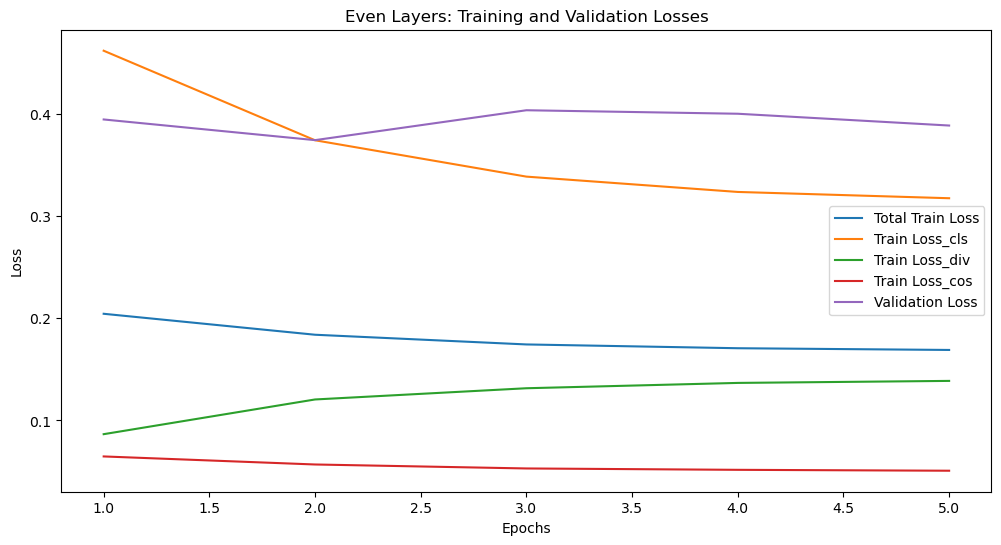

In [45]:


epochs_list = range(1, num_epochs + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_list, even_train_losses, label='Total Train Loss')
plt.plot(epochs_list, even_train_losses_cls, label='Train Loss_cls')
plt.plot(epochs_list, even_train_losses_div, label='Train Loss_div')
plt.plot(epochs_list, even_train_losses_cos, label='Train Loss_cos')
plt.plot(epochs_list, even_eval_losses, label='Validation Loss')

plt.title('Even Layers: Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Odd Train

In [46]:
# Lists to store losses for each epoch
odd_train_losses = []
odd_train_losses_cls = []
odd_train_losses_div = []
odd_train_losses_cos = []
odd_eval_losses = []

for epoch in range(num_epochs):
    model_odd.train()
    teacher_model.eval()
    train_loss = 0
    train_loss_cls = 0
    train_loss_div = 0
    train_loss_cos = 0
    
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        # compute student output
        outputs = model_odd(**batch) 
        # compute teacher output
        with torch.no_grad():
            output_teacher = teacher_model(**batch)

        # assert size
        assert outputs.logits.size() == output_teacher.logits.size()
        
        # cls loss 
        loss_cls  = outputs.loss
        train_loss_cls += loss_cls.item()
        # distillation loss
        loss_div = criterion_div(outputs.logits, output_teacher.logits)
        train_loss_div += loss_div.item()
        # cosine loss
        loss_cos = criterion_cos(output_teacher.logits, outputs.logits, torch.ones(output_teacher.logits.size()[0]).to(device))
        train_loss_cos += loss_cos.item()
        
        # Average the loss and return it
        loss = (loss_cls + loss_div + loss_cos) / 3
        
        train_loss += loss.item()
        loss.backward()
        # accelerator.backward(loss)
        # Step with optimizer
        optimizer_odd.step()
        lr_scheduler_odd.step()
        optimizer_odd.zero_grad()
        progress_bar.update(1)
        
    odd_train_losses.append(train_loss / len(train_dataloader))
    odd_train_losses_cls.append(train_loss_cls / len(train_dataloader))
    odd_train_losses_div.append(train_loss_div / len(train_dataloader))
    odd_train_losses_cos.append(train_loss_cos / len(train_dataloader))

    print(f'Epoch at {epoch+1}: Train loss {train_loss/len(train_dataloader):.4f}:')
    print(f'  - Loss_cls: {train_loss_cls/len(train_dataloader):.4f}')
    print(f'  - Loss_div: {train_loss_div/len(train_dataloader):.4f}')
    print(f'  - Loss_cos: {train_loss_cos/len(train_dataloader):.4f}')
    
    model_odd.eval()
    eval_loss = 0
    for batch in eval_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model_odd(**batch)
            
        loss_cls = outputs.loss
        predictions = outputs.logits.argmax(dim=-1)

        eval_loss += loss_cls.item()
        # predictions, references = accelerator.gather((predictions, batch["labels"]))
        metric.add_batch(
            predictions=predictions, 
            references=batch["labels"])
        
    eval_metric = metric.compute()
    eval_metrics += eval_metric['accuracy'] 
    odd_eval_losses.append(eval_loss / len(eval_dataloader))  # Save the evaluation loss for plotting
    
    print(f"Epoch at {epoch+1}: Test Acc {eval_metric['accuracy']:.4f}")
    
print('Avg Metric', eval_metrics/num_epochs)

1878it [11:16,  3.50it/s]                          

Epoch at 1: Train loss 0.2046:
  - Loss_cls: 0.4569
  - Loss_div: 0.0906
  - Loss_cos: 0.0663
Epoch at 1: Test Acc 0.9250


2191it [13:09,  3.49it/s]

Epoch at 2: Train loss 0.1831:
  - Loss_cls: 0.3681
  - Loss_div: 0.1233
  - Loss_cos: 0.0578
Epoch at 2: Test Acc 0.9270


2504it [15:03,  3.46it/s]

Epoch at 3: Train loss 0.1758:
  - Loss_cls: 0.3376
  - Loss_div: 0.1340
  - Loss_cos: 0.0557
Epoch at 3: Test Acc 0.9180


2817it [16:56,  3.46it/s]

Epoch at 4: Train loss 0.1713:
  - Loss_cls: 0.3231
  - Loss_div: 0.1381
  - Loss_cos: 0.0528
Epoch at 4: Test Acc 0.9080


3130it [18:49,  3.50it/s]

Epoch at 5: Train loss 0.1694:
  - Loss_cls: 0.3170
  - Loss_div: 0.1400
  - Loss_cos: 0.0513
Epoch at 5: Test Acc 0.9290
Avg Metric 1.8412000000000002


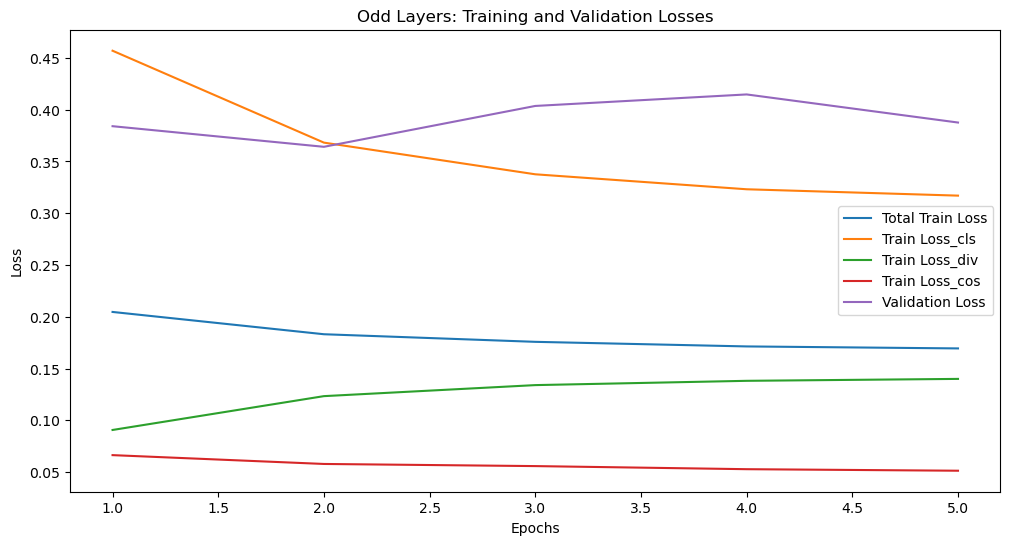

In [47]:
epochs_list = range(1, num_epochs + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_list, odd_train_losses, label='Total Train Loss')
plt.plot(epochs_list, odd_train_losses_cls, label='Train Loss_cls')
plt.plot(epochs_list, odd_train_losses_div, label='Train Loss_div')
plt.plot(epochs_list, odd_train_losses_cos, label='Train Loss_cos')
plt.plot(epochs_list, odd_eval_losses, label='Validation Loss')

plt.title('Odd Layers: Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Appendix(Teacher Model)

In [48]:
# teacher model

lr = 5e-5
#training hyperparameters
optimizer = optim.Adam(params=teacher_model.parameters(), lr=lr)

progress_bar = tqdm(range(num_training_steps))
eval_metrics = 0

for epoch in range(num_epochs):
    teacher_model.train()
    train_loss = 0
    for step, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}
        output_teacher = teacher_model(**batch)
        # cls loss 
        loss = output_teacher.loss
        train_loss += loss.item()
        loss.backward()
        # accelerator.backward(loss)
        # Step with optimizer
        optimizer.step()
        lr_scheduler_even.step()
        optimizer.zero_grad()
        progress_bar.update(1)

    print(f'Epoch at {epoch+1}: Train loss {train_loss/len(train_dataloader):.4f}:')
    
    teacher_model.eval()
    for step, batch in enumerate(eval_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = teacher_model(**batch)
    
        predictions = outputs.logits.argmax(dim=-1)
        # predictions, references = accelerator.gather((predictions, batch["labels"]))
        metric.add_batch(
            predictions=predictions, 
            references=batch["labels"])
        
    eval_metric = metric.compute()
    eval_metrics += eval_metric['accuracy'] 
    print(f"Epoch at {epoch+1}: Test Acc {eval_metric['accuracy']:.4f}")
    
print('Avg Metric', eval_metrics/num_epochs)

3130it [18:52,  2.76it/s]


Epoch at 1: Train loss 0.2373:
Epoch at 1: Test Acc 0.9310


Epoch at 2: Train loss 0.1082:
Epoch at 2: Test Acc 0.9190


Epoch at 3: Train loss 0.0588:
Epoch at 3: Test Acc 0.8940


Epoch at 4: Train loss 0.0291:
Epoch at 4: Test Acc 0.8990


Epoch at 5: Train loss 0.0279:
Epoch at 5: Test Acc 0.9400
Avg Metric 0.9166000000000001


## Testing

### Testing through even layer

In [49]:
model_even.eval()

text = ["I love you", "I hate you"]

inputs = tokenizer(text, padding=True, truncation=True, max_length=128, return_tensors="pt")

input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

with torch.no_grad():
    outputs = model_even(input_ids.to(device), attention_mask=attention_mask.to(device))

predictions = torch.argmax(outputs.logits, dim=1)

for i, pred in enumerate(predictions):
    print(f"Text: {text[i]}")
    print(f"Predicted Label: {id2label[pred.item()]}\n")

Text: I love you
Predicted Label: non-toxic

Text: I hate you
Predicted Label: toxic



### Testing through odd layer

In [50]:
model_odd.eval()

text = ["I love you", "I hate you"]

inputs = tokenizer(text, padding=True, truncation=True, max_length=128, return_tensors="pt")

input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

with torch.no_grad():
    outputs = model_odd(input_ids.to(device), attention_mask=attention_mask.to(device))

predictions = torch.argmax(outputs.logits, dim=1)

for i, pred in enumerate(predictions):
    print(f"Text: {text[i]}")
    print(f"Predicted Label: {id2label[pred.item()]}\n")

Text: I love you
Predicted Label: toxic

Text: I hate you
Predicted Label: toxic



## Saving model

In [51]:
## Save the even model
save_path = "./model/train_even_model"
model_even.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

('./model/train_even_model\\tokenizer_config.json',
 './model/train_even_model\\special_tokens_map.json',
 './model/train_even_model\\vocab.txt',
 './model/train_even_model\\added_tokens.json',
 './model/train_even_model\\tokenizer.json')

In [52]:
## Save the odd model
save_path = "./model/train_odd_model"
model_odd.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)



('./model/train_odd_model\\tokenizer_config.json',
 './model/train_odd_model\\special_tokens_map.json',
 './model/train_odd_model\\vocab.txt',
 './model/train_odd_model\\added_tokens.json',
 './model/train_odd_model\\tokenizer.json')

## LoRA (Low-Rank Adaptation)

LoRA works by adding pairs of rank decomposition matrices to transformer layers, typically focusing on attention weights. During inference, these adapter weights can be merged with the base model, resulting in no additional latency overhead. LoRA is particularly useful for adapting large language models to specific tasks or domains while keeping resource requirements manageable. You can read more about LoRA in the [LoRA paper](https://arxiv.org/pdf/2106.09685).

LoRA works by adding pairs of rank decomposition matrices to transformer layers, typically focusing on attention weights. During inference, these adapter weights can be merged with the base model, resulting in no additional latency overhead. LoRA is particularly useful for adapting large language models to specific tasks or domains while keeping resource requirements manageable.

In [54]:
from peft import LoraConfig, TaskType, get_peft_model

student_12_layer_model = AutoModelForSequenceClassification.from_pretrained(
    teacher_id, 
    num_labels = NUM_LABELS,
    id2label = id2label,
    label2id = label2id,
)
student_12_layer_model

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [55]:
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, 
    inference_mode=False, 
    r=8, 
    lora_alpha=32, 
    lora_dropout=0.1,
    bias="none",
    target_modules=["query", "key", "value"]
)
student_12_layer_model = get_peft_model(student_12_layer_model, peft_config)

In [56]:
# No need for .to(device) here; Trainer handles device placement
student_12_layer_model.print_trainable_parameters()

trainable params: 443,906 || all params: 109,927,684 || trainable%: 0.4038


In [57]:
from sklearn.metrics import accuracy_score
def compute_metrics(eval_preds):
  
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)  # Get class predictions from logits

    # Compute accuracy
    accuracy = accuracy_score(labels, predictions)

    # You can add more metrics here (e.g., F1, precision, recall)
    return {"accuracy": accuracy}

In [58]:
# Check raw dataset
print("Raw train_dataset[0]:", tokenized_dataset['train'][0])

# Create a DataLoader manually to inspect a batch
from torch.utils.data import DataLoader
temp_dataloader = DataLoader(tokenized_dataset['train'], batch_size=2, collate_fn=DataCollatorWithPadding(tokenizer=tokenizer))
batch = next(iter(temp_dataloader))
print("Batch keys:", batch.keys())

Raw train_dataset[0]: {'label': tensor(0), 'input_ids': tensor([  101,  2024,  2119,  2327, 16585,  5244,  1997,  3306,  4761,  1010,
         2021,  1996,  3306,  2544,  1997,  1996,  2171,  2038,  2025,  2042,
         2443,  1999,  4445,  1997,  1996,  5816,  4790,  1012,  2065,  2017,
         2215,  2000,  4863,  1996,  3802, 10536, 20570,  1997,  1996,  2327,
        16585,  2213,  1010,  2017,  2064,  2079,  2009,  2917,  1010,  2021,
         1045,  2052, 16755,  2017,  2025,  2000,  2224,  1996, 15522, 12440,
         2144,  2009,  2003,  4895, 16416, 20782,  2005,  1996,  2691,  2394,
         5882,  1012,   102,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
        

In [59]:
from transformers import TrainingArguments, Trainer, default_data_collator
training_args = TrainingArguments(
    output_dir="student-lora",
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    max_steps=-1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    evaluation_strategy="steps", 
    save_strategy="steps",        
    save_steps=500,               
    eval_steps=500,              
    fp16=True
)

tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "token_type_ids", "label"])

trainer = Trainer(
    model=student_12_layer_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

c:\Users\Ishika\anaconda3\envs\nlpassignmnet\Lib\site-packages\transformers\training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Ishika\AppData\Local\Temp\ipykernel_46884\1309042500.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [60]:
trainer.train()
trainer.save_model()
student_12_layer_model.save_pretrained("student-lora")

Step,Training Loss,Validation Loss,Accuracy
500,0.287200,0.206477,0.914539
1000,0.187400,0.295403,0.885555
1500,0.177000,0.171205,0.932790
2000,0.154300,0.176234,0.932085
2500,0.149600,0.221862,0.917124


### Inference

In [61]:
student_12_layer_model.eval()

text = ["I love you", "I hate you"]

inputs = tokenizer(text, padding=True, truncation=True, max_length=128, return_tensors="pt")

input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

with torch.no_grad():
    outputs = student_12_layer_model(input_ids.to(device), attention_mask=attention_mask.to(device))

predictions = torch.argmax(outputs.logits, dim=1)

for i, pred in enumerate(predictions):
    print(f"Text: {text[i]}")
    print(f"Predicted Label: {id2label[pred.item()]}\n")

Text: I love you
Predicted Label: non-toxic

Text: I hate you
Predicted Label: toxic



##  Evaluation and Analysis

### Even Layer Model

This model uses only the even-numbered layers of BERT (e.g., layers 0, 2, 4, etc.), reducing the model’s size. In term of Performance, it performed both test sentences ("I love you" as non-toxic, "I hate you" as toxic), suggesting better generalization than the odd layers model. The training and validation loss plots look stable, and it likely benefits from the teacher’s guidance via distillation.Even layers might preserve more of BERT’s initial processing (starting at layer 0), giving it a slight edge over odd layers. Still, it’s only half the model, so it’s not as powerful as the full BERT.


## Odd Layer Model

This uses only the odd-numbered layers (e.g., layers 1, 3, 5, etc.), also a slimmed-down version of BERT.Like the even layers model, it’s trained with the same loss combination. In term of performance, the inference test shows it correctly identifies "I hate you" as toxic but mislabels "I love you" as toxic. This suggests it might be overly aggressive in flagging text as toxic, possibly due to overfitting or poor generalization. Without test set accuracy, we can’t say for sure, but the validation loss plot shows a downward trend, indicating it learns something but just not perfectly.Using only odd layers cuts the model’s depth in half, potentially losing critical contextual understanding that BERT relies on across all layers. The loss terms try to align it with the teacher, but the reduced capacity might limit its ability to capture nuanced patterns.

## LoRA Model

This uses the full BERT model but applies LoRA to adapt it efficiently, adding low-rank matrices to the attention layers (query, key, value). In terms of performance, the validation accuracy peaks at 0.9328, which is close to the teacher’s best test accuracy (0.9400). Inference on the test sentences is spot-on, matching the even layers model’s success. Given its validation strength, it’s reasonable to assume test accuracy would be in the 0.92–0.94 range.LoRA keeps all 12 layers but only fine-tunes a tiny fraction of parameters, making it efficient without sacrificing much power. It adapts the full BERT architecture to the task, leveraging its full contextual understanding.


## Observation

| Model Type   |  Training Loss| Avg Metric |
|--------|------------------|--------|
| Odd Layer| 0.9290         | 1.84120   |  
|  Even Layer|0.9280        | 0.91980  | 





LoRA Model 

|Step	|Training Loss|	Validation Loss	|Accuracy |
|-------|--------------|--------------|------------|
|500	|0.287200	|0.206477	|0.914539|
|1000	|0.187400	|0.295403	|0.885555|
|1500	|0.177000	|0.171205   |0.932790|
|2000	|0.154300	|0.176234	|0.932085|
|2500	|0.149600	|0.221862	|0.917124|


### Challenges encountered



- Class Imbalance Issue:

  - Training data had a stark 90:10 class imbalance (91,778 non-toxic vs. 10,346 toxic).

  - Models overpredicted the majority class.

  - No direct mitigation but used downsampling.

- Distilled Models (Odd/Even Layers)
   -  Improper balancing could lead to one loss dominating, skewing learning. Without fine-tuning, the model may prioritize mimicking the teacher over learning the task itself.

   - The odd layers model’s tendency to overpredict "toxic" suggests it struggled with imbalance, which overwhelmed its limited capacity. With fewer toxic samples, generalization suffered.

   - Cutting BERT’s 12 layers to 6 significantly weakened its ability to capture complex patterns.Halving depth risks losing nuance, and distillation alone can’t fully compensate if the model is too small.

- LoRA (Low-Rank Adaptation)
    -  Required extra steps to integrate with the peft library and Trainer, including configuring LoraConfig, wrapping the model with get_peft_model, and ensuring compatibility with TrainingArguments.

    - Despite training fewer parameters, LoRA still used the full BERT architecture, leading to higher inference and memory usage than distilled models. 

    - Despite a strong validation accuracy of 0.9328, the lack of downsampling or class weighting meant the model might still be biased.

    -  LoRA trained for 2 epochs, longer per epoch than distilled models due to using the full BERT architecture. While parameter efficiency improved